1. Import Libraries

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from tensorflow.keras.models import load_model

## 2. Load Feature-Engineered Dataset

In [108]:
df = pd.read_csv("/content/ganga_water_quality_features.csv")

df.head()

,location,year,do,bod,fecal_coliform,do_good,bod_good,fecal_good,water_quality_score,year_index,station_id,do_lag1,bod_lag1,fecal_coliform_lag1,do_change,bod_change,fecal_coliform_change
0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2012,7.1,5.1,3450.0,1,0,0,1,1,0,7.2,4.0,3408.0,-0.1,1.1,42.0
1,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2013,8.2,3.6,6475.0,1,0,0,1,2,0,7.1,5.1,3450.0,1.1,-1.5,3025.0
2,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2014,8.6,3.8,26000.0,1,0,0,1,3,0,8.2,3.6,6475.0,0.4,0.2,19525.0
3,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2015,7.9,4.1,21300.0,1,0,0,1,4,0,8.6,3.8,26000.0,-0.7,0.3,-4700.0
4,GANGA AT DAKSHINESHWAR,2012,6.1,4.1,493750.0,1,0,0,1,1,1,7.8,4.0,270333.0,-1.7,0.1,223417.0


In [109]:
df = pd.read_csv("/content/ganga_water_quality_features.csv")

df.head()

,location,year,do,bod,fecal_coliform,do_good,bod_good,fecal_good,water_quality_score,year_index,station_id,do_lag1,bod_lag1,fecal_coliform_lag1,do_change,bod_change,fecal_coliform_change
0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2012,7.1,5.1,3450.0,1,0,0,1,1,0,7.2,4.0,3408.0,-0.1,1.1,42.0
1,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2013,8.2,3.6,6475.0,1,0,0,1,2,0,7.1,5.1,3450.0,1.1,-1.5,3025.0
2,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2014,8.6,3.8,26000.0,1,0,0,1,3,0,8.2,3.6,6475.0,0.4,0.2,19525.0
3,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2015,7.9,4.1,21300.0,1,0,0,1,4,0,8.6,3.8,26000.0,-0.7,0.3,-4700.0
4,GANGA AT DAKSHINESHWAR,2012,6.1,4.1,493750.0,1,0,0,1,1,1,7.8,4.0,270333.0,-1.7,0.1,223417.0


In [110]:
print("Dataset shape:", df.shape)

Dataset shape: (36, 17)


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   location               36 non-null     object 
 1   year                   36 non-null     int64  
 2   do                     36 non-null     float64
 3   bod                    36 non-null     float64
 4   fecal_coliform         36 non-null     float64
 5   do_good                36 non-null     int64  
 6   bod_good               36 non-null     int64  
 7   fecal_good             36 non-null     int64  
 8   water_quality_score    36 non-null     int64  
 9   year_index             36 non-null     int64  
 10  station_id             36 non-null     int64  
 11  do_lag1                36 non-null     float64
 12  bod_lag1               36 non-null     float64
 13  fecal_coliform_lag1    36 non-null     float64
 14  do_change              36 non-null     float64
 15  bod_chan

## 3. Check Available Years and Stations

In [112]:
print("Available years:", sorted(df["year"].unique()))
print("Number of stations:", df["station_id"].nunique())

Available years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
Number of stations: 9


In [113]:
df[["station_id", "location"]].drop_duplicates()

,station_id,location
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P."
4,1,GANGA AT DAKSHINESHWAR
8,2,GANGA AT GARHMUKTESHWAR
12,4,"GANGA AT KANNAUJ D/S, U.P"
16,5,GANGA AT KANNAUJ U/S (RAJGHAT)
20,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION)
24,7,GANGA AT KANPUR U/S (RANIGHAT)
28,8,GANGA AT TRIGHAT (GHAZIPUR)
32,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P"


4. Load the Best Model

In [114]:
# Load best LSTM model and scalers

from tensorflow.keras.models import load_model
import joblib

model = load_model("/content/do_prediction_model.keras")

scaler_X = joblib.load("/content/scaler_X.pkl")
scaler_y = joblib.load("/content/scaler_y.pkl")

print("Best Model: LSTM")
print("Model and scalers loaded successfully.")

Best Model: LSTM
Model and scalers loaded successfully.


In [115]:
import os

print("Model:", os.path.exists("/content/do_prediction_model.keras"))
print("Scaler X:", os.path.exists("/content/scaler_X.pkl"))
print("Scaler Y:", os.path.exists("/content/scaler_y.pkl"))

Model: True
Scaler X: True
Scaler Y: True


## 5. Define Forecasting Features

In [116]:
features = [
    "year_index",
    "station_id",
    "do_lag1",
    "bod_lag1",
    "fecal_coliform_lag1"
]

target = "do"

## 6. Prepare Latest Available Data

In [117]:
latest_data = df[df["year"] == 2015].copy()


print("Latest year:", latest_data["year"].max())
print("Number of stations:", len(latest_data))

latest_data[
    [
        "station_id",
        "location",
        "year",
        "do",
        "bod",
        "fecal_coliform"
    ]
]

Latest year: 2015
Number of stations: 9


,station_id,location,year,do,bod,fecal_coliform
3,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2015,7.9,4.1,21300.0
7,1,GANGA AT DAKSHINESHWAR,2015,6.6,4.8,182500.0
11,2,GANGA AT GARHMUKTESHWAR,2015,7.7,3.0,733.0
15,4,"GANGA AT KANNAUJ D/S, U.P",2015,7.9,3.7,2930.0
19,5,GANGA AT KANNAUJ U/S (RAJGHAT),2015,8.4,3.5,2270.0
23,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),2015,6.5,5.5,20889.0
27,7,GANGA AT KANPUR U/S (RANIGHAT),2015,8.2,2.9,3267.0
31,8,GANGA AT TRIGHAT (GHAZIPUR),2015,7.5,4.2,22000.0
35,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",2015,7.3,4.9,32500.0


7. Create 2016 Forecast Input

In [118]:
forecast_df = latest_data.copy()

forecast_df["year"] = 2016
forecast_df["year_index"] = 5

forecast_df["do_lag1"] = latest_data["do"]
forecast_df["bod_lag1"] = latest_data["bod"]
forecast_df["fecal_coliform_lag1"] = latest_data["fecal_coliform"]

In [119]:
forecast_df[
    [
        "station_id",
        "location",
        "year",
        "year_index",
        "do_lag1",
        "bod_lag1",
        "fecal_coliform_lag1"
    ]
]

,station_id,location,year,year_index,do_lag1,bod_lag1,fecal_coliform_lag1
3,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2016,5,7.9,4.1,21300.0
7,1,GANGA AT DAKSHINESHWAR,2016,5,6.6,4.8,182500.0
11,2,GANGA AT GARHMUKTESHWAR,2016,5,7.7,3.0,733.0
15,4,"GANGA AT KANNAUJ D/S, U.P",2016,5,7.9,3.7,2930.0
19,5,GANGA AT KANNAUJ U/S (RAJGHAT),2016,5,8.4,3.5,2270.0
23,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),2016,5,6.5,5.5,20889.0
27,7,GANGA AT KANPUR U/S (RANIGHAT),2016,5,8.2,2.9,3267.0
31,8,GANGA AT TRIGHAT (GHAZIPUR),2016,5,7.5,4.2,22000.0
35,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",2016,5,7.3,4.9,32500.0


## 8. Generate DO Prediction

In [120]:
X_future = forecast_df[features].copy()

# Scale input features
X_future_scaled = scaler_X.transform(X_future)

# Reshape for LSTM
X_future_dl = X_future_scaled.reshape(
    X_future_scaled.shape[0],
    X_future_scaled.shape[1],
    1
)

# Predict
y_future_scaled = model.predict(
    X_future_dl,
    verbose=0
)

# Convert back to original DO scale
y_future = scaler_y.inverse_transform(
    y_future_scaled
).flatten()

forecast_df["predicted_do"] = y_future

forecast_df[
    [
        "station_id",
        "location",
        "predicted_do"
    ]
]

,station_id,location,predicted_do
3,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",7.747945
7,1,GANGA AT DAKSHINESHWAR,7.379063
11,2,GANGA AT GARHMUKTESHWAR,7.736700
15,4,"GANGA AT KANNAUJ D/S, U.P",7.764496
19,5,GANGA AT KANNAUJ U/S (RAJGHAT),7.776708
23,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),7.759508
27,7,GANGA AT KANPUR U/S (RANIGHAT),7.775426
31,8,GANGA AT TRIGHAT (GHAZIPUR),7.783530
35,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",7.753108


## 9. Water Quality Status

A project-defined DO threshold of 5 mg/L is used to identify stations
that may require attention.

- Predicted DO > 5 mg/L → Safe
- Predicted DO ≤ 5 mg/L → Warning

This threshold is used for prototype early-warning visualization and
does not represent a complete regulatory water-quality classification.

In [121]:
forecast_df["status"] = np.where(
    forecast_df["predicted_do"] > 5,
    "Safe",
    "Warning"
)

In [122]:
forecast_df[
    [
        "station_id",
        "location",
        "predicted_do",
        "status"
    ]
]

,station_id,location,predicted_do,status
3,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",7.747945,Safe
7,1,GANGA AT DAKSHINESHWAR,7.379063,Safe
11,2,GANGA AT GARHMUKTESHWAR,7.736700,Safe
15,4,"GANGA AT KANNAUJ D/S, U.P",7.764496,Safe
19,5,GANGA AT KANNAUJ U/S (RAJGHAT),7.776708,Safe
23,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),7.759508,Safe
27,7,GANGA AT KANPUR U/S (RANIGHAT),7.775426,Safe
31,8,GANGA AT TRIGHAT (GHAZIPUR),7.783530,Safe
35,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",7.753108,Safe


## 10. Forecast Summary

In [123]:
forecast_df["status"].value_counts()

,count
status,
Safe,9


In [124]:
forecast_df["status"].value_counts(normalize=True) * 100

,proportion
status,
Safe,100.0


## 11. Predicted Dissolved Oxygen by Station

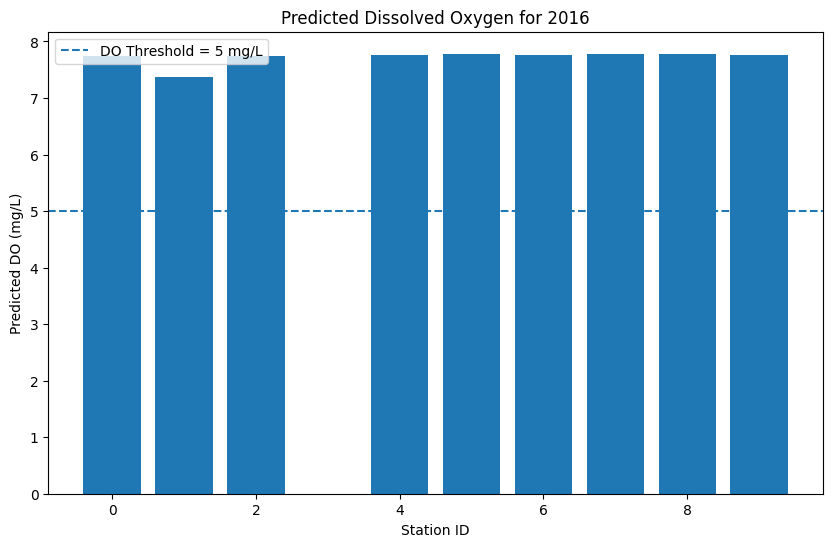

In [125]:
plt.figure(figsize=(10, 6))

plt.bar(
    forecast_df["station_id"],
    forecast_df["predicted_do"]
)

plt.axhline(
    y=5,
    linestyle="--",
    label="DO Threshold = 5 mg/L"
)

plt.title("Predicted Dissolved Oxygen for 2016")
plt.xlabel("Station ID")
plt.ylabel("Predicted DO (mg/L)")
plt.legend()

plt.show()

12. Station-wise Forecast Table

In [126]:
forecast_summary = forecast_df[
    [
        "station_id",
        "location",
        "year",
        "predicted_do",
        "status"
    ]
].copy()

forecast_summary

,station_id,location,year,predicted_do,status
3,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2016,7.747945,Safe
7,1,GANGA AT DAKSHINESHWAR,2016,7.379063,Safe
11,2,GANGA AT GARHMUKTESHWAR,2016,7.736700,Safe
15,4,"GANGA AT KANNAUJ D/S, U.P",2016,7.764496,Safe
19,5,GANGA AT KANNAUJ U/S (RAJGHAT),2016,7.776708,Safe
23,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),2016,7.759508,Safe
27,7,GANGA AT KANPUR U/S (RANIGHAT),2016,7.775426,Safe
31,8,GANGA AT TRIGHAT (GHAZIPUR),2016,7.783530,Safe
35,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",2016,7.753108,Safe


13. Sort by Risk

In [127]:
forecast_summary.sort_values(
    "predicted_do"
)

,station_id,location,year,predicted_do,status
7,1,GANGA AT DAKSHINESHWAR,2016,7.379063,Safe
11,2,GANGA AT GARHMUKTESHWAR,2016,7.736700,Safe
3,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2016,7.747945,Safe
35,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",2016,7.753108,Safe
23,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),2016,7.759508,Safe
15,4,"GANGA AT KANNAUJ D/S, U.P",2016,7.764496,Safe
27,7,GANGA AT KANPUR U/S (RANIGHAT),2016,7.775426,Safe
19,5,GANGA AT KANNAUJ U/S (RAJGHAT),2016,7.776708,Safe
31,8,GANGA AT TRIGHAT (GHAZIPUR),2016,7.783530,Safe


## 14. Save Forecast Results

In [128]:
forecast_summary.to_csv(
    "/content/ganga_do_forecast_2016.csv",
    index=False
)

In [129]:
os.path.exists(
    "/content/ganga_do_forecast_2016.csv"
)

True

15. Download the Forecast CSV

In [130]:
from google.colab import files

files.download(
    "/content/ganga_do_forecast_2016.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [131]:
forecast_summary = forecast_df[
    [
        "station_id",
        "location",
        "year",
        "predicted_do",
        "status"
    ]
].copy()

forecast_summary.to_csv(
    "/content/ganga_do_forecast_2016.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


## 15. Forecasting Findings

- The selected machine learning model was used to generate future Dissolved Oxygen (DO) predictions.
- The latest available observations from 2015 were used to generate the 2016 forecast.
- Predictions were generated for the monitored Ganga River stations.
- A DO threshold of 5 mg/L was used to identify stations requiring attention.
- Stations with predicted DO above 5 mg/L were classified as Safe.
- Stations with predicted DO at or below 5 mg/L were classified as Warning.
- The forecast output will be used as an input for the early-warning component of Aquanga.

### Limitation

The current dataset contains only 50 observations from 10 stations over 5 years.
Therefore, the forecast should be considered a prototype. A larger and more frequent
time-series dataset would be required for reliable long-term forecasting.